In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

filePath = "../data/players.xlsx"

df = pd.read_excel(filePath)

# Filtrar só Whole Session
ws = df[df['Segment Name'] == 'Whole Session']

# Métricas relevantes
metrics = [
    'Session Load', 'Distance (m)', 'High Intensity Running (m)',
    'Sprint Distance (m)', 'Top Speed (kph)', 'Accelerations',
    'Decelerations', 'Metres per Minute (m)'
]

# Uma linha por atleta (média dos jogos)
player_df = ws.groupby('Athlete ID')[metrics].mean().dropna()

# Normalizar
scaler = StandardScaler()
X = scaler.fit_transform(player_df)

In [9]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

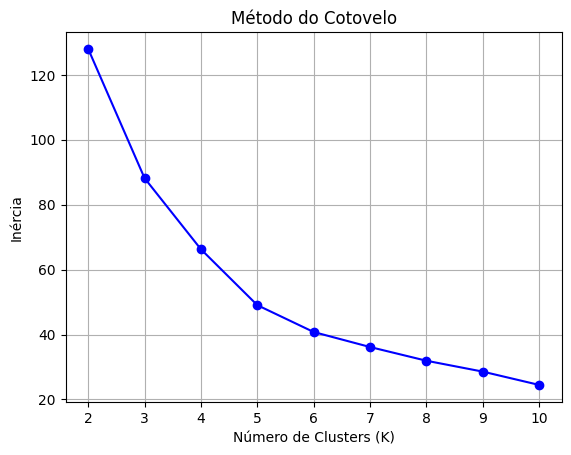

In [11]:
import matplotlib.pyplot as plt

plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.xticks(K_range)
plt.grid(True)
plt.show()